# Benchmark v2 — richer metrics + bilateral edge model

Adds to v1:
- **Metrics:** MAE, RMSE, R2, **log-R2**, **Spearman**, SMAPE (all models)
- **Bilateral risk as EDGE features** (Option 2): an edge-aware GNN where each trade edge carries the (exporter→importer) GDELT risk
- **Plots** saved to `plots/`

Run top to bottom; the **driver** runs the whole study.

In [1]:
import os, csv
from datetime import datetime
import numpy as np, pandas as pd, torch
import torch.nn as nn
import gc
import dgl, dgl.function as fn
from dgl.nn import GATConv, GraphConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("training on:", DEVICE)

MISSING = 'median'      # 'median' | 'drop' | 'rf'

BILAT_KEEP = 'gdelt_bilateral_by_pair_year.parquet'
BILAT_TOPK = 'gdelt_bilateral_topk.parquet'
KEEPALL    = 'gdelt_features_by_country_year.parquet'   # <-- ADD
TOPK       = 'gdelt_features_topk.parquet'              # <-- ADD


SCORER_COMBOS = [
    ('ka_ka', KEEPALL, BILAT_KEEP),   # keepall nodes, keepall pairs
    ('tk_tk', TOPK,    BILAT_TOPK),   # topk nodes,    topk pairs
    ('ka_tk', KEEPALL, BILAT_TOPK),   # keepall nodes, topk pairs
    ('tk_ka', TOPK,    BILAT_KEEP),   # topk nodes,    keepall pairs
]

GDELT_COLS = ['events_total','score_mean','score_max','score_vol','goldstein_wmean','tone_mean','active_months']
BASE_COLS  = ['refYear','cmdCode','dist','gdpcap_d','gdpcap_o','pop_o','pop_d']
BILAT_COLS = ['pair_events','pair_score_mean','pair_score_max','pair_gold_mean']
RESULTS_FILE = 'results_v2.csv'
os.makedirs('plots', exist_ok=True)
PREDS = {}   # run_key -> (y_true, y_pred) for plotting
AGG_SPEC = {'primaryValue':'sum','dist':'first','gdpcap_d':'first',
            'gdpcap_o':'first','pop_o':'first','pop_d':'first'}

training on: cuda


## Metrics + logging

In [2]:
def _smape(yt, yp):
    d=(np.abs(yt)+np.abs(yp))/2; m=d>0
    return np.mean(np.abs(yt[m]-yp[m])/d[m])*100 if m.sum() else np.nan

def _spearman(a,b):
    if len(a)<3: return np.nan
    return pd.Series(a).corr(pd.Series(b), method='spearman')

def compute_metrics(yt, yp):
    ytl=np.log1p(np.clip(yt,0,None)); ypl=np.log1p(np.clip(yp,0,None))
    return dict(mae=mean_absolute_error(yt,yp),
                rmse=mean_squared_error(yt,yp)**0.5,
                r2=r2_score(yt,yp),
                log_r2=(r2_score(ytl,ypl) if len(yt)>2 else np.nan),
                spearman=_spearman(yt,yp),
                smape=_smape(yt,yp))

def log_result(model, fusion, scoring, gdelt, risk_level, agg_mode, missing, tranche, met, n, notes=''):
    row={'timestamp':datetime.now().isoformat(timespec='seconds'),
         'model':model,'fusion':fusion,'scoring':scoring,'gdelt':gdelt,
         'risk_level':risk_level,'agg_mode':agg_mode,'missing':missing,'tranche':tranche,   # <-- added 'missing'
         'mae':round(met['mae'],2),'rmse':round(met['rmse'],2),'r2':round(met['r2'],4),
         'log_r2':round(float(met['log_r2']),4),'spearman':round(float(met['spearman']),4),
         'smape':round(met['smape'],2),'n':int(n),'notes':notes}
    new=not os.path.exists(RESULTS_FILE)
    with open(RESULTS_FILE,'a',newline='') as f:
        w=csv.DictWriter(f,fieldnames=row.keys())
        if new: w.writeheader()
        w.writerow(row)
    return row

def report_and_log(model, use_gdelt, scoring, agg_mode, y_true, y_pred, fusion_override=None, risk_level='node'):
    fus = fusion_override if fusion_override is not None else ('concat' if use_gdelt else 'none')
    sc  = scoring if use_gdelt else 'none'
    PREDS[f'{model}|{fus}|{sc}|{agg_mode}|{risk_level}'] = (y_true, y_pred)
    print(f'\n=== {model} gdelt={use_gdelt} scoring={sc} agg={agg_mode} fusion={fus} risk={risk_level} ===')
    for label, thr in [('all',None),('1M',1e6),('10M',1e7),('100M',1e8)]:
        m = np.ones_like(y_true,bool) if thr is None else (y_true>=thr)
        if m.sum()<10: continue
        met=compute_metrics(y_true[m],y_pred[m])
        print(f"  {label:4s} n={int(m.sum()):>6,} R2={met['r2']:.3f} logR2={met['log_r2']:.3f} "
              f"rho={met['spearman']:.3f} RMSE={met['rmse']:,.0f}")
        log_result(model, fus, sc, use_gdelt, risk_level, agg_mode, MISSING, label, met, int(m.sum()))

## GDELT merges (node + bilateral edge) and aggregation

In [3]:
def add_gdelt(agg, gdelt_file):
    cy=pd.read_parquet(gdelt_file)
    out=agg.copy()
    out['_r']=out['reporterCode'].astype('Int64').astype(str); out['_y']=out['refYear'].astype('Int64').astype(str)
    cy['_r']=cy['reporterCode'].astype('Int64').astype(str);  cy['_y']=cy['year'].astype('Int64').astype(str)
    out=out.merge(cy[['_r','_y']+GDELT_COLS], on=['_r','_y'], how='left')
    out[GDELT_COLS]=out[GDELT_COLS].fillna(0)
    return out.drop(columns=['_r','_y'])

def build_agg(df, use_gdelt, gdelt_file, agg_mode='sum'):
    if agg_mode == 'spec':                       # Step B: per-feature aggregation
        agg = df.groupby(['refYear','reporterCode','cmdCode']).agg(
            **{k:(k,op) for k,op in AGG_SPEC.items()}).reset_index()
    else:                                        # old behaviour kept for comparison
        grav = 'first' if agg_mode=='first' else 'sum'
        agg = (df.groupby(['refYear','reporterCode','cmdCode'])
                 .agg(primaryValue=('primaryValue','mean'), dist=('dist','first'),
                      gdpcap_d=('gdpcap_d',grav), gdpcap_o=('gdpcap_o',grav),
                      pop_o=('pop_o',grav), pop_d=('pop_d',grav)).reset_index())
    agg['y_log'] = np.log1p(agg['primaryValue'].clip(lower=0))   # Step A: log AFTER agg
    if use_gdelt:
        agg = add_gdelt(agg, gdelt_file)
    return agg

def edge_features(df_rows, bilat_file):
    '''Per-row (reporter,partner,year) bilateral risk vector, aligned to df_rows order.'''
    b=pd.read_parquet(bilat_file)
    k=df_rows[['reporterCode','partnerCode','refYear']].copy()
    k['reporterCode']=k['reporterCode'].astype('Int64'); k['partnerCode']=k['partnerCode'].astype('Int64'); k['refYear']=k['refYear'].astype('Int64')
    b['reporterCode']=b['reporterCode'].astype('Int64'); b['partnerCode']=b['partnerCode'].astype('Int64'); b['year']=b['year'].astype('Int64')
    m=k.merge(b, left_on=['reporterCode','partnerCode','refYear'], right_on=['reporterCode','partnerCode','year'], how='left')
    return m[BILAT_COLS].fillna(0).to_numpy(dtype='float32')

## Load + split (once)

In [4]:
from sklearn.experimental import enable_iterative_imputer   # required import
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

def handle_missing(train, test, strategy='median'):
    cols=['gdpcap_o','pop_o','gdpcap_d','pop_d','dist']
    if strategy=='drop':
        return train.dropna(subset=cols).copy(), test.dropna(subset=cols).copy()
    if strategy=='median':
        fill = train[cols].median()                       # fit on train only
        return train.fillna(fill).copy(), test.fillna(fill).copy()
    if strategy=='rf':
        imp = IterativeImputer(estimator=RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=0),
                               max_iter=5, random_state=0)
        tr, te = train.copy(), test.copy()
        tr[cols] = imp.fit_transform(train[cols])          # FIT on train only
        te[cols] = imp.transform(test[cols])               # APPLY to test (no refit)
        return tr, te
    raise ValueError(strategy)

def load_and_split(path='all_products_ready.parquet'):
    # column-subset load: only what the models use (keeps 26M rows in RAM)
    cols = ['refYear','reporterCode','partnerCode','cmdCode',
            'gdpcap_o','pop_o','gdpcap_d','pop_d','dist','primaryValue']
    df = pd.read_parquet(path, columns=cols)
    for c in ['gdpcap_o','gdpcap_d','dist','pop_o','pop_d','primaryValue','refYear','cmdCode','reporterCode','partnerCode']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['gdpcap_o']/=1e6; df['gdpcap_d']/=1e6; df['dist']/=1e3
    df = df[df['cmdCode'].notna()].copy(); df['cmdCode']=df['cmdCode'].astype(int)
    d = df.drop_duplicates(['refYear','reporterCode','partnerCode','cmdCode']).reset_index(drop=True)
    tr_full = d[d['refYear'].isin([2017,2018,2019,2020,2021,2022])].copy()
    te      = d[d['refYear']==2023].copy()
    tr_full, te = handle_missing(tr_full, te, strategy=MISSING)
    train_data, val_data = [], []
    for _, grp in tr_full.groupby('reporterCode'):
        if len(grp) < 5:
            train_data.append(grp); continue
        a,b = train_test_split(grp, test_size=0.2, random_state=42)
        train_data.append(a); val_data.append(b)
    train_data = pd.concat(train_data); val_data = pd.concat(val_data)
    print(f'train {len(train_data):,} | val {len(val_data):,} | test2023 {len(te):,}')
    return train_data, val_data, te

train_data, val_data, data_2023 = load_and_split('all_products_ready.parquet')

train 18,249,109 | val 4,562,331 | test2023 3,505,132


## Models — node (GAT/GCN + fusion) and edge (bilateral)

In [5]:
class GATRegressionModel(nn.Module):
    def __init__(s,inf,h=32,heads=4):
        super().__init__(); s.c1=GATConv(inf,h,heads); s.c2=GATConv(h*heads,1,heads)
    def forward(s,g,x): return s.c2(g, torch.relu(s.c1(g,x).flatten(1))).mean(1)

class GCNRegressionModel(nn.Module):
    def __init__(s,inf,h=32):
        super().__init__(); s.c1=GraphConv(inf,h,allow_zero_in_degree=True); s.c2=GraphConv(h,1,allow_zero_in_degree=True)
    def forward(s,g,x): return s.c2(g, torch.relu(s.c1(g,x))).squeeze(-1)

class BlendGAT(nn.Module):
    def __init__(s,nt,ng,proj=16,h=32,heads=4):
        super().__init__(); s.tp=nn.Linear(nt,proj); s.gp=nn.Linear(ng,proj)
        s.alpha=nn.Parameter(torch.tensor(0.5)); s.c1=GATConv(proj,h,heads); s.c2=GATConv(h*heads,1,heads)
    def forward(s,g,xt,xg):
        a=torch.sigmoid(s.alpha); f=a*torch.relu(s.gp(xg))+(1-a)*torch.relu(s.tp(xt))
        return s.c2(g, torch.relu(s.c1(g,f).flatten(1))).mean(1)

class AttnGAT(nn.Module):
    def __init__(s,nt,ng,proj=16,h=32,heads=4):
        super().__init__(); s.tp=nn.Linear(nt,proj); s.gp=nn.Linear(ng,proj)
        s.attn=nn.MultiheadAttention(proj,1,batch_first=True); s.c1=GATConv(proj,h,heads); s.c2=GATConv(h*heads,1,heads)
    def forward(s,g,xt,xg):
        st=torch.stack([torch.relu(s.tp(xt)),torch.relu(s.gp(xg))],dim=1)
        f=s.attn(st,st,st)[0].mean(1)
        return s.c2(g, torch.relu(s.c1(g,f).flatten(1))).mean(1)

# --- edge-aware conv: neighbor message = f(neighbor_node, EDGE_risk) ---
class EdgeConv(nn.Module):
    def __init__(s,inf,ef,out):
        super().__init__(); s.msg=nn.Linear(inf+ef,out); s.slf=nn.Linear(inf,out)
    def forward(s,g,x,ef):
        with g.local_scope():
            g.ndata['h']=x; g.edata['e']=ef
            g.update_all(lambda e:{'m':s.msg(torch.cat([e.src['h'],e.data['e']],1))}, fn.mean('m','agg'))
            return torch.relu(s.slf(x)+g.ndata['agg'])

class EdgeRiskGNN(nn.Module):
    '''Bilateral risk on edges: risk enters the message passed along each trade link.'''
    def __init__(s,inf,ef,h=32):
        super().__init__(); s.l1=EdgeConv(inf,ef,h); s.l2=EdgeConv(h,ef,1)
    def forward(s,g,x,ef): return s.l2(g, s.l1(g,x,ef), ef).squeeze(-1)

from dgl.nn import GATv2Conv

class GATv2RegressionModel(nn.Module):
    def __init__(s,inf,h=32,heads=4):
        super().__init__(); s.c1=GATv2Conv(inf,h,heads,allow_zero_in_degree=True); s.c2=GATv2Conv(h*heads,1,heads,allow_zero_in_degree=True)
    def forward(s,g,x): return s.c2(g, torch.relu(s.c1(g,x).flatten(1))).mean(1)

class TabTransformer(nn.Module):
    def __init__(self, n_feats, d=32, heads=4, layers=2):
        super().__init__()
        self.d=d
        self.feat_emb = nn.Linear(1, d)                       # each scalar feature -> d-dim token
        self.pos = nn.Parameter(torch.randn(n_feats, d)*0.02) # per-feature positional embedding
        enc = nn.TransformerEncoderLayer(d, heads, d*2, batch_first=True)
        self.tf = nn.TransformerEncoder(enc, layers)
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d,1))
    def forward(self, x):                # x: (batch, n_feats)
        t = self.feat_emb(x.unsqueeze(-1)) + self.pos      # (batch, n_feats, d)
        t = self.tf(t)
        return self.head(t.mean(1)).squeeze(-1)            # pool tokens -> scalar

from dgl.nn import EdgeGATConv

class EdgeGAT(nn.Module):
    """Attention + edge features: bilateral risk influences the attention weights."""
    def __init__(s, inf, ef, h=32, heads=4):
        super().__init__()
        s.c1 = EdgeGATConv(inf, ef, h, heads, allow_zero_in_degree=True)
        s.c2 = EdgeGATConv(h*heads, ef, 1, heads, allow_zero_in_degree=True)
    def forward(s, g, x, efeat):
        x = torch.relu(s.c1(g, x, efeat).flatten(1))   # (N, heads*h)
        return s.c2(g, x, efeat).mean(1).squeeze(-1)    # (N,)

## Runners: node graph models, RF, and the bilateral edge model

In [6]:
# ================= CELL 1 of runners — device helper + node models + RF + TabTF =================
import torch, gc
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("default DEVICE:", DEVICE)

def with_fallback(fn, *args, **kwargs):
    """Try GPU; on CUDA OOM, clean up and retry on CPU."""
    if torch.cuda.is_available():
        try:
            return fn(*args, device=torch.device('cuda'), **kwargs)
        except torch.cuda.OutOfMemoryError:
            print("  GPU OOM -> falling back to CPU")
            gc.collect(); torch.cuda.empty_cache()
            return fn(*args, device=torch.device('cpu'), **kwargs)
    return fn(*args, device=torch.device('cpu'), **kwargs)

def _eval_graph(model, df_eval, cmap, sf, st, feat_cols, use_gdelt, gdelt_file,
                agg_mode='sum', fusion='concat', nt=None, bs=10000, device=torch.device('cpu')):
    d=df_eval.copy()
    for c in ['gdpcap_o','pop_o','gdpcap_d','pop_d','dist']: d[c]=d[c].fillna(d[c].mean())
    d['nID']=d['reporterCode'].map(cmap); d['pID']=d['partnerCode'].map(cmap)
    d=d.dropna(subset=['nID','pID']).copy()
    if len(d)==0: return None,None
    agg=build_agg(d,use_gdelt,gdelt_file,agg_mode)
    emap={c:i for i,c in enumerate(agg['reporterCode'])}
    Xe=sf.transform(agg[feat_cols]); ye=st.transform(agg[['y_log']])
    d['eN']=d['reporterCode'].map(emap); d['eP']=d['partnerCode'].map(emap)
    d=d.dropna(subset=['eN','eP']); d['eN']=d['eN'].astype(int); d['eP']=d['eP'].astype(int)
    eg=dgl.graph((d['eN'].to_numpy(),d['eP'].to_numpy())); eg.ndata['feat']=torch.tensor(Xe,dtype=torch.float32); eg=dgl.add_self_loop(eg)
    eg=eg.to(device)                                                              # <-- graph to device
    fused=fusion in ('blend','attention'); model.eval(); preds=[]; N=eg.num_nodes()
    for i in range(0,N,bs):
        bn=list(range(i,min(i+bs,N))); bg=eg.subgraph(torch.tensor(bn,device=device)); ft=bg.ndata['feat']
        with torch.no_grad():
            out=model(bg,ft[:,:nt],ft[:,nt:]) if fused else model(bg,ft)
            preds.append(out.unsqueeze(1))
    yp=np.expm1(st.inverse_transform(torch.cat(preds,0).view(-1,1).cpu().numpy()).flatten())   # <-- .cpu()
    yt=np.expm1(st.inverse_transform(ye).flatten())
    return yt,yp

def run_graph(kind, train_data, data_2023, use_gdelt, scoring, gdelt_file,
              fusion='concat', epochs=100, agg_mode='sum', device=torch.device('cpu')):
    feat_cols=BASE_COLS+(GDELT_COLS if use_gdelt else [])
    agg=build_agg(train_data,use_gdelt,gdelt_file,agg_mode); cmap={c:i for i,c in enumerate(agg['reporterCode'])}
    td=train_data.copy(); td['nodeID']=td['reporterCode'].map(cmap)
    sf,st=MinMaxScaler(),MinMaxScaler(); Xtr=sf.fit_transform(agg[feat_cols]); ytr=st.fit_transform(agg[['y_log']])
    g=dgl.graph((td['nodeID'].to_numpy(),td['partnerCode'].map(cmap).to_numpy())); g.ndata['feat']=torch.tensor(Xtr,dtype=torch.float32); g=dgl.add_self_loop(g)
    g=g.to(device)                                                               # <-- graph to device
    fused=fusion in ('blend','attention'); nt=len(BASE_COLS)
    if fusion=='blend': model=BlendGAT(nt,len(GDELT_COLS))
    elif fusion=='attention': model=AttnGAT(nt,len(GDELT_COLS))
    elif kind=='GAT': model=GATRegressionModel(len(feat_cols))
    elif kind=='GATv2': model=GATv2RegressionModel(len(feat_cols))
    else: model=GCNRegressionModel(len(feat_cols))
    model=model.to(device)                                                       # <-- model to device
    ytr_t=torch.tensor(ytr[:,0],dtype=torch.float32).to(device)                  # <-- target to device
    opt=torch.optim.Adam(model.parameters(),lr=0.01); crit=nn.MSELoss(); N=g.num_nodes(); bs=10000; nb=N//bs+(N%bs>0)
    for ep in range(epochs):
        model.train()
        for i in range(nb):
            bn=list(range(i*bs,min((i+1)*bs,N))); bg=g.subgraph(torch.tensor(bn,device=device)); ft=bg.ndata['feat']
            logit=model(bg,ft[:,:nt],ft[:,nt:]) if fused else model(bg,ft)
            loss=crit(logit.view(-1,1),ytr_t[bn].view(-1,1))
            opt.zero_grad(); loss.backward(); opt.step()
    yt,yp=_eval_graph(model,data_2023,cmap,sf,st,feat_cols,use_gdelt,gdelt_file,agg_mode,fusion,nt,device=device)
    if yt is not None: report_and_log(kind,use_gdelt,scoring,agg_mode,yt,yp,fusion_override=(fusion if use_gdelt else 'none'))
    if fusion=='blend': print(f'   learned alpha = {torch.sigmoid(model.alpha).item():.3f}')
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return model

def run_rf(train_data, data_2023, use_gdelt, scoring, gdelt_file, agg_mode='sum', device=None):
    # RF is sklearn = CPU only; device arg ignored (kept for uniform driver calls)
    feat_cols=BASE_COLS+(GDELT_COLS if use_gdelt else [])
    tr=build_agg(train_data,use_gdelt,gdelt_file,agg_mode).dropna(subset=feat_cols+['primaryValue'])
    te=build_agg(data_2023,use_gdelt,gdelt_file,agg_mode).dropna(subset=feat_cols+['primaryValue'])
    sf,st=MinMaxScaler(),MinMaxScaler(); Xtr=sf.fit_transform(tr[feat_cols]); Xte=sf.transform(te[feat_cols])
    ytr=st.fit_transform(tr[['y_log']]); yte=st.transform(te[['y_log']])
    rf=RandomForestRegressor(n_estimators=200,max_depth=25,n_jobs=2,random_state=0).fit(Xtr,ytr.ravel())
    yp=np.expm1(st.inverse_transform(rf.predict(Xte).reshape(-1,1)).flatten()); yt=np.expm1(st.inverse_transform(yte).flatten())
    report_and_log('RF',use_gdelt,scoring,agg_mode,yt,yp)
    gc.collect()
    return rf

def run_tabtransformer(train_data, data_2023, use_gdelt, scoring, gdelt_file, agg_mode='sum', epochs=100, device=torch.device('cpu')):
    feat_cols=BASE_COLS+(GDELT_COLS if use_gdelt else [])
    tr=build_agg(train_data,use_gdelt,gdelt_file,agg_mode).dropna(subset=feat_cols+['primaryValue'])
    te=build_agg(data_2023,use_gdelt,gdelt_file,agg_mode).dropna(subset=feat_cols+['primaryValue'])
    sf,st=MinMaxScaler(),MinMaxScaler()
    Xtr=torch.tensor(sf.fit_transform(tr[feat_cols]),dtype=torch.float32).to(device)
    Xte=torch.tensor(sf.transform(te[feat_cols]),dtype=torch.float32).to(device)
    ytr=torch.tensor(st.fit_transform(tr[['y_log']]),dtype=torch.float32).to(device)
    model=TabTransformer(len(feat_cols)).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3); crit=nn.MSELoss(); bs=2048; N=len(Xtr)
    for ep in range(epochs):
        model.train(); perm=torch.randperm(N,device=device)
        for i in range(0,N,bs):
            idx=perm[i:i+bs]; opt.zero_grad()
            loss=crit(model(Xtr[idx]).view(-1,1), ytr[idx].view(-1,1)); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad(): pred=model(Xte).view(-1,1).cpu().numpy()
    yp=np.expm1(st.inverse_transform(pred).flatten())
    yt=np.expm1(st.inverse_transform(st.transform(te[['y_log']])).flatten())
    report_and_log('TabTF',use_gdelt,scoring,agg_mode,yt,yp)
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return model

def run_edge_graph(train_data, data_2023, scoring, bilat_file, agg_mode='first', epochs=100, device=torch.device('cpu')):
    '''Bilateral EDGE model (thin): gravity node feats + bilateral risk on edges, no attention.'''
    feat_cols=BASE_COLS
    agg=build_agg(train_data,False,None,agg_mode); cmap={c:i for i,c in enumerate(agg['reporterCode'])}
    td=train_data.copy(); td['nID']=td['reporterCode'].map(cmap); td['pID']=td['partnerCode'].map(cmap)
    td=td.dropna(subset=['nID','pID']).copy(); td['nID']=td['nID'].astype(int); td['pID']=td['pID'].astype(int)
    sf,st=MinMaxScaler(),MinMaxScaler(); Xtr=sf.fit_transform(agg[feat_cols]); ytr=st.fit_transform(agg[['y_log']])
    ef=MinMaxScaler().fit_transform(edge_features(td, bilat_file))
    g=dgl.graph((td['nID'].to_numpy(),td['pID'].to_numpy())); g.ndata['feat']=torch.tensor(Xtr,dtype=torch.float32)
    g.edata['ef']=torch.tensor(ef,dtype=torch.float32); g=dgl.add_self_loop(g, fill_data=0.)
    g=g.to(device)                                                          # <-- graph to device
    model=EdgeRiskGNN(len(feat_cols),len(BILAT_COLS)).to(device)            # <-- model to device
    ytr_t=torch.tensor(ytr[:,0],dtype=torch.float32).to(device)             # <-- target to device
    opt=torch.optim.Adam(model.parameters(),lr=0.01); crit=nn.MSELoss(); efull=g.edata['ef']
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        out=model(g, g.ndata['feat'], efull)
        loss=crit(out.view(-1,1), ytr_t.view(-1,1)); loss.backward(); opt.step()
    yt,yp=_eval_edge(model,data_2023,cmap,sf,st,feat_cols,bilat_file,agg_mode,device=device)
    if yt is not None: report_and_log('EdgeGNN',True,scoring,agg_mode,yt,yp,fusion_override='edge',risk_level='bilateral')
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return model

def _eval_edge(model, df_eval, cmap, sf, st, feat_cols, bilat_file, agg_mode, device=torch.device('cpu')):
    d=df_eval.copy()
    for c in ['gdpcap_o','pop_o','gdpcap_d','pop_d','dist']: d[c]=d[c].fillna(d[c].mean())
    d['nID']=d['reporterCode'].map(cmap); d['pID']=d['partnerCode'].map(cmap)
    d=d.dropna(subset=['nID','pID']).copy()
    if len(d)==0: return None,None
    agg=build_agg(d,False,None,agg_mode); emap={c:i for i,c in enumerate(agg['reporterCode'])}
    Xe=sf.transform(agg[feat_cols]); ye=st.transform(agg[['y_log']])
    d['eN']=d['reporterCode'].map(emap); d['eP']=d['partnerCode'].map(emap)
    d=d.dropna(subset=['eN','eP']); d['eN']=d['eN'].astype(int); d['eP']=d['eP'].astype(int)
    ef=MinMaxScaler().fit_transform(edge_features(d, bilat_file))
    eg=dgl.graph((d['eN'].to_numpy(),d['eP'].to_numpy())); eg.ndata['feat']=torch.tensor(Xe,dtype=torch.float32)
    eg.edata['ef']=torch.tensor(ef,dtype=torch.float32); eg=dgl.add_self_loop(eg, fill_data=0.)
    eg=eg.to(device)                                                        # <-- graph to device
    model.eval()
    with torch.no_grad(): out=model(eg, eg.ndata['feat'], eg.edata['ef'])
    yp=np.expm1(st.inverse_transform(out.view(-1,1).cpu().numpy()).flatten())   # <-- .cpu()
    yt=np.expm1(st.inverse_transform(ye).flatten())
    return yt,yp

def run_edge_gat(train_data, data_2023, scoring, bilat_file, agg_mode='first', epochs=100, device=torch.device('cpu')):
    '''Bilateral EDGE model (thin) with attention: EdgeGAT.'''
    feat_cols=BASE_COLS
    agg=build_agg(train_data,False,None,agg_mode); cmap={c:i for i,c in enumerate(agg['reporterCode'])}
    td=train_data.copy(); td['nID']=td['reporterCode'].map(cmap); td['pID']=td['partnerCode'].map(cmap)
    td=td.dropna(subset=['nID','pID']).copy(); td['nID']=td['nID'].astype(int); td['pID']=td['pID'].astype(int)
    sf,st=MinMaxScaler(),MinMaxScaler(); Xtr=sf.fit_transform(agg[feat_cols]); ytr=st.fit_transform(agg[['y_log']])
    ef=MinMaxScaler().fit_transform(edge_features(td, bilat_file))
    g=dgl.graph((td['nID'].to_numpy(),td['pID'].to_numpy())); g.ndata['feat']=torch.tensor(Xtr,dtype=torch.float32)
    g.edata['ef']=torch.tensor(ef,dtype=torch.float32); g=dgl.add_self_loop(g, fill_data=0.)
    g=g.to(device)
    model=EdgeGAT(len(feat_cols),len(BILAT_COLS)).to(device)
    ytr_t=torch.tensor(ytr[:,0],dtype=torch.float32).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=0.01); crit=nn.MSELoss(); efull=g.edata['ef']
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        out=model(g, g.ndata['feat'], efull)
        loss=crit(out.view(-1,1), ytr_t.view(-1,1)); loss.backward(); opt.step()
    yt,yp=_eval_edge(model,data_2023,cmap,sf,st,feat_cols,bilat_file,agg_mode,device=device)
    if yt is not None: report_and_log('EdgeGAT',True,scoring,agg_mode,yt,yp,fusion_override='edge',risk_level='bilateral')
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return model

default DEVICE: cuda


In [7]:
import dgl.function as fn

class EdgeGATv2Conv(nn.Module):
    """GATv2 dynamic attention + edge features, single-head for clarity."""
    def __init__(s, in_feats, edge_feats, out_feats):
        super().__init__()
        s.fc_src  = nn.Linear(in_feats, out_feats, bias=False)
        s.fc_dst  = nn.Linear(in_feats, out_feats, bias=False)
        s.fc_edge = nn.Linear(edge_feats, out_feats, bias=False)
        s.attn    = nn.Linear(out_feats, 1, bias=False)   # applied AFTER leakyrelu = GATv2
        s.leaky   = nn.LeakyReLU(0.2)
        s.out_feats = out_feats
    def forward(s, g, x, efeat):
        with g.local_scope():
            g.srcdata['xs'] = s.fc_src(x)
            g.dstdata['xd'] = s.fc_dst(x)
            g.edata['xe']   = s.fc_edge(efeat)
            # combine src + dst + edge on each edge, THEN nonlinearity, THEN score (v2 order)
            g.apply_edges(lambda e: {'e': s.attn(s.leaky(e.src['xs'] + e.dst['xd'] + e.data['xe']))})
            g.edata['a'] = dgl.nn.functional.edge_softmax(g, g.edata['e'])
            # message = attention-weighted (neighbor + edge)
            g.apply_edges(lambda e: {'m': e.data['a'] * (e.src['xs'] + e.data['xe'])})
            g.update_all(fn.copy_e('m','m'), fn.sum('m','h'))
            return g.dstdata['h']

class EdgeGATv2(nn.Module):
    def __init__(s, inf, ef, h=32):
        super().__init__()
        s.c1 = EdgeGATv2Conv(inf, ef, h)
        s.c2 = EdgeGATv2Conv(h, ef, 1)
    def forward(s, g, x, efeat):
        x = torch.relu(s.c1(g, x, efeat))
        return s.c2(g, x, efeat).squeeze(-1)

In [8]:
# ============ CELL 3 of runners — FULL edge models (GPU-ready) ============
FULL_NODE_COLS = ['refYear','cmdCode','gdpcap_d','gdpcap_o','pop_o','pop_d'] + GDELT_COLS
FULL_EDGE_COLS = BILAT_COLS + ['dist']

def edge_features_full(df_rows, bilat_file):
    b = pd.read_parquet(bilat_file)
    k = df_rows[['reporterCode','partnerCode','refYear','dist']].copy()
    for c in ['reporterCode','partnerCode','refYear']: k[c]=k[c].astype('Int64')
    b['reporterCode']=b['reporterCode'].astype('Int64'); b['partnerCode']=b['partnerCode'].astype('Int64'); b['year']=b['year'].astype('Int64')
    m = k.merge(b, left_on=['reporterCode','partnerCode','refYear'],
                right_on=['reporterCode','partnerCode','year'], how='left')
    m[BILAT_COLS]=m[BILAT_COLS].fillna(0); m['dist']=m['dist'].fillna(m['dist'].median())
    return m[FULL_EDGE_COLS].to_numpy(dtype='float32')

def run_edge_full(kind, train_data, data_2023, combo, gdelt_file, bilat_file,
                  agg_mode='first', epochs=100, device=torch.device('cpu')):
    agg = build_agg(train_data, True, gdelt_file, agg_mode)
    cmap = {c:i for i,c in enumerate(agg['reporterCode'])}
    td = train_data.copy(); td['nID']=td['reporterCode'].map(cmap); td['pID']=td['partnerCode'].map(cmap)
    td = td.dropna(subset=['nID','pID']).copy(); td['nID']=td['nID'].astype(int); td['pID']=td['pID'].astype(int)
    sf,st=MinMaxScaler(),MinMaxScaler()
    Xtr=sf.fit_transform(agg[FULL_NODE_COLS]); ytr=st.fit_transform(agg[['y_log']])
    ef=MinMaxScaler().fit_transform(edge_features_full(td, bilat_file))
    g=dgl.graph((td['nID'].to_numpy(),td['pID'].to_numpy())); g.ndata['feat']=torch.tensor(Xtr,dtype=torch.float32)
    g.edata['ef']=torch.tensor(ef,dtype=torch.float32); g=dgl.add_self_loop(g, fill_data=0.)
    g=g.to(device)                                                          # <-- graph to device
    ni,ei=len(FULL_NODE_COLS),len(FULL_EDGE_COLS)
    if   kind=='EdgeGAT':   model = EdgeGAT(ni,ei)
    elif kind=='EdgeGATv2': model = EdgeGATv2(ni,ei)
    else:                   model = EdgeRiskGNN(ni,ei)
    model=model.to(device)                                                  # <-- model to device
    ytr_t=torch.tensor(ytr[:,0],dtype=torch.float32).to(device)             # <-- target to device
    opt=torch.optim.Adam(model.parameters(),lr=0.01); crit=nn.MSELoss(); efull=g.edata['ef']
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        out=model(g, g.ndata['feat'], efull)
        loss=crit(out.view(-1,1), ytr_t.view(-1,1))
        loss.backward(); opt.step()
    yt,yp=_eval_edge_full(model, data_2023, cmap, sf, st, gdelt_file, bilat_file, agg_mode, device=device)
    if yt is not None:
        report_and_log(kind+'_full', True, combo, agg_mode, yt, yp, fusion_override='edge_full', risk_level='bilateral')
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return model

def _eval_edge_full(model, df_eval, cmap, sf, st, gdelt_file, bilat_file, agg_mode, device=torch.device('cpu')):
    d=df_eval.copy()
    for c in ['gdpcap_o','pop_o','gdpcap_d','pop_d','dist']: d[c]=d[c].fillna(d[c].mean())
    d['nID']=d['reporterCode'].map(cmap); d['pID']=d['partnerCode'].map(cmap)
    d=d.dropna(subset=['nID','pID']).copy()
    if len(d)==0: return None,None
    agg=build_agg(d, True, gdelt_file, agg_mode); emap={c:i for i,c in enumerate(agg['reporterCode'])}
    Xe=sf.transform(agg[FULL_NODE_COLS]); ye=st.transform(agg[['y_log']])
    d['eN']=d['reporterCode'].map(emap); d['eP']=d['partnerCode'].map(emap)
    d=d.dropna(subset=['eN','eP']); d['eN']=d['eN'].astype(int); d['eP']=d['eP'].astype(int)
    ef=MinMaxScaler().fit_transform(edge_features_full(d, bilat_file))
    eg=dgl.graph((d['eN'].to_numpy(),d['eP'].to_numpy())); eg.ndata['feat']=torch.tensor(Xe,dtype=torch.float32)
    eg.edata['ef']=torch.tensor(ef,dtype=torch.float32); eg=dgl.add_self_loop(eg, fill_data=0.)
    eg=eg.to(device)                                                        # <-- graph to device
    model.eval()
    with torch.no_grad(): out=model(eg, eg.ndata['feat'], eg.edata['ef'])
    yp=np.expm1(st.inverse_transform(out.view(-1,1).cpu().numpy()).flatten())   # <-- .cpu()
    yt=np.expm1(st.inverse_transform(ye).flatten())
    return yt,yp

In [9]:
#print(GDELT_COLS)
print(BILAT_COLS)

['pair_events', 'pair_score_mean', 'pair_score_max', 'pair_gold_mean']


In [10]:
"""import dgl, torch
g = dgl.add_self_loop(dgl.graph(([0,1,2],[1,2,0])))
try:
    m = EdgeGATv2(4, 3, 8)
    out = m(g, torch.randn(3,4), torch.randn(g.num_edges(),3))
    print("✓ forward works, output shape:", out.shape)   # want torch.Size([3])
except Exception as e:
    print("✗ failed:", type(e).__name__, e)"""

'import dgl, torch\ng = dgl.add_self_loop(dgl.graph(([0,1,2],[1,2,0])))\ntry:\n    m = EdgeGATv2(4, 3, 8)\n    out = m(g, torch.randn(3,4), torch.randn(g.num_edges(),3))\n    print("✓ forward works, output shape:", out.shape)   # want torch.Size([3])\nexcept Exception as e:\n    print("✗ failed:", type(e).__name__, e)'

## Build the bilateral edge-risk file (run once; needs the events parquet + country_codes.py)

In [11]:

"""
BILAT_FILE='gdelt_bilateral_by_pair_year.parquet'
if not os.path.exists(BILAT_FILE):
    from country_codes import ISO3_2_M49
    iso2m49={**ISO3_2_M49,'TWN':'490'}
    CRIT=['14','17','18','19','20']
    ev=pd.read_parquet('gdelt_chip_events_2017_2023.parquet')
    ev['date']=pd.to_datetime(ev['date'],errors='coerce')
    ev=ev.dropna(subset=['date','Actor1CountryCode','Actor2CountryCode'])
    ev=ev[ev['date'].dt.year.between(2017,2023)]
    ev=ev[ev['EventRootCode'].astype(str).isin(CRIT)].copy()
    ev['year']=ev['date'].dt.year
    ev['gold']=pd.to_numeric(ev['GoldsteinScale'],errors='coerce'); ev['ment']=pd.to_numeric(ev['NumMentions'],errors='coerce')
    ev['score']=ev['gold'].abs()*ev['ment']
    g=ev.groupby(['Actor1CountryCode','Actor2CountryCode','year'])
    b=g.agg(pair_events=('GLOBALEVENTID','size'), pair_score_mean=('score','mean'),
            pair_score_max=('score','max'), pair_gold_mean=('gold','mean')).reset_index()
    b['reporterCode']=b['Actor1CountryCode'].map(iso2m49); b['partnerCode']=b['Actor2CountryCode'].map(iso2m49)
    b=b.dropna(subset=['reporterCode','partnerCode'])
    b['reporterCode']=b['reporterCode'].astype(int); b['partnerCode']=b['partnerCode'].astype(int)
    b.to_parquet(BILAT_FILE,index=False)
    print('SAVED',b.shape,'->',BILAT_FILE)
else:
    print('exists:',BILAT_FILE)
pd.read_parquet(BILAT_FILE).head()"""

"\nBILAT_FILE='gdelt_bilateral_by_pair_year.parquet'\nif not os.path.exists(BILAT_FILE):\n    from country_codes import ISO3_2_M49\n    iso2m49={**ISO3_2_M49,'TWN':'490'}\n    CRIT=['14','17','18','19','20']\n    ev=pd.read_parquet('gdelt_chip_events_2017_2023.parquet')\n    ev['date']=pd.to_datetime(ev['date'],errors='coerce')\n    ev=ev.dropna(subset=['date','Actor1CountryCode','Actor2CountryCode'])\n    ev=ev[ev['date'].dt.year.between(2017,2023)]\n    ev=ev[ev['EventRootCode'].astype(str).isin(CRIT)].copy()\n    ev['year']=ev['date'].dt.year\n    ev['gold']=pd.to_numeric(ev['GoldsteinScale'],errors='coerce'); ev['ment']=pd.to_numeric(ev['NumMentions'],errors='coerce')\n    ev['score']=ev['gold'].abs()*ev['ment']\n    g=ev.groupby(['Actor1CountryCode','Actor2CountryCode','year'])\n    b=g.agg(pair_events=('GLOBALEVENTID','size'), pair_score_mean=('score','mean'),\n            pair_score_max=('score','max'), pair_gold_mean=('gold','mean')).reset_index()\n    b['reporterCode']=b['Acto

## DRIVER — full study

In [ ]:
import os, pickle, torch, gc

os.makedirs('trained_models', exist_ok=True)

def save_model(model, name):
    """Save sklearn via pickle, torch models via state_dict."""
    if hasattr(model, 'state_dict'):                    # torch
        torch.save(model.state_dict(), f'trained_models/{name}.pt')
    else:                                               # sklearn (RF)
        with open(f'trained_models/{name}.pkl','wb') as f: pickle.dump(model, f)

def done(name):
    return os.path.exists(f'trained_models/{name}.pt') or os.path.exists(f'trained_models/{name}.pkl')

def run_once(name, fn, *args, **kwargs):
    """Skip if already trained; otherwise run, save, and free memory."""
    if done(name):
        print(f'⏭  skip {name} (already trained)')
        return
    print(f'▶  {name}')
    model = fn(*args, **kwargs)
    if model is not None: save_model(model, name)
    gc.collect()                                        # free memory between runs

CONDITIONS = [('none',False,None),('keepall',True,KEEPALL),('topk',True,TOPK)]

# --- Block 1 ---
for agg_mode in ['first','spec']:
    for scoring,use_gdelt,gfile in CONDITIONS:
        tag=f'{agg_mode}_{scoring}'
        run_once(f'RF_{tag}',    run_rf,            train_data,data_2023,use_gdelt,scoring,gfile,agg_mode)
        run_once(f'TabTF_{tag}', run_tabtransformer,train_data,data_2023,use_gdelt,scoring,gfile,agg_mode)
        run_once(f'GCN_{tag}',   run_graph,'GCN',   train_data,data_2023,use_gdelt,scoring,gfile,agg_mode=agg_mode)
        run_once(f'GAT_{tag}',   run_graph,'GAT',   train_data,data_2023,use_gdelt,scoring,gfile,agg_mode=agg_mode)
        run_once(f'GATv2_{tag}', run_graph,'GATv2', train_data,data_2023,use_gdelt,scoring,gfile,agg_mode=agg_mode)

# --- Block 2 ---
for fusion in ['blend','attention']:
    for scoring,gfile in [('keepall',KEEPALL),('topk',TOPK)]:
        run_once(f'GAT_{fusion}_{scoring}', run_graph,'GAT',train_data,data_2023,True,scoring,gfile,fusion=fusion,agg_mode='first')

# --- Block 3 ---
BILAT_FILE='gdelt_bilateral_by_pair_year.parquet'
run_once('EdgeGNN_thin', run_edge_graph, train_data,data_2023,'bilateral',BILAT_FILE,agg_mode='first')
run_once('EdgeGAT_thin', run_edge_gat,   train_data,data_2023,'bilateral',BILAT_FILE,agg_mode='first')
for combo,node_file,pair_file in SCORER_COMBOS:
    run_once(f'EdgeGNN_full_{combo}',   run_edge_full,'EdgeGNN',  train_data,data_2023,combo,node_file,pair_file)
    run_once(f'EdgeGAT_full_{combo}',   run_edge_full,'EdgeGAT',  train_data,data_2023,combo,node_file,pair_file)
    run_once(f'EdgeGATv2_full_{combo}', run_edge_full,'EdgeGATv2',train_data,data_2023,combo,node_file,pair_file)

print('\n=== ALL RUNS DONE ===')

⏭  skip RF_first_none (already trained)
⏭  skip TabTF_first_none (already trained)
⏭  skip GCN_first_none (already trained)
⏭  skip GAT_first_none (already trained)
⏭  skip GATv2_first_none (already trained)
⏭  skip RF_first_keepall (already trained)
⏭  skip TabTF_first_keepall (already trained)
⏭  skip GCN_first_keepall (already trained)
⏭  skip GAT_first_keepall (already trained)
⏭  skip GATv2_first_keepall (already trained)
⏭  skip RF_first_topk (already trained)
⏭  skip TabTF_first_topk (already trained)
⏭  skip GCN_first_topk (already trained)
⏭  skip GAT_first_topk (already trained)
⏭  skip GATv2_first_topk (already trained)
⏭  skip RF_spec_none (already trained)
⏭  skip TabTF_spec_none (already trained)
⏭  skip GCN_spec_none (already trained)
⏭  skip GAT_spec_none (already trained)
⏭  skip GATv2_spec_none (already trained)
⏭  skip RF_spec_keepall (already trained)
⏭  skip TabTF_spec_keepall (already trained)
⏭  skip GCN_spec_keepall (already trained)
⏭  skip GAT_spec_keepall (al

## Results tables

In [182]:
r=pd.read_csv(RESULTS_FILE)
r=r.drop_duplicates(['model','fusion','scoring','gdelt','risk_level','agg_mode','tranche'],keep='last')
main=r[r.fusion.isin(['none','concat'])]
for am in ['sum','first']:
    for metric in ['r2','log_r2','spearman']:
        sub=main[(main.tranche=='all')&(main.agg_mode==am)].copy()
        sub['cond']=np.where(~sub.gdelt,'no-GDELT','GDELT/'+sub.scoring)
        print(f'\n--- agg={am} | {metric} | all flows ---')
        print(sub.pivot_table(index='model',columns='cond',values=metric).round(3))
print('\n--- GAT fusion (agg=first, all flows) ---')
gf=r[(r.model=='GAT')&(r.gdelt)&(r.agg_mode=='first')&(r.tranche=='all')]
print(gf.pivot_table(index='fusion',columns='scoring',values='r2').round(3))
print('\n--- Bilateral edge model (all tranches) ---')
print(r[r.model=='EdgeGNN'][['tranche','r2','log_r2','spearman','rmse']].to_string(index=False))


--- agg=sum | r2 | all flows ---
Empty DataFrame
Columns: []
Index: []

--- agg=sum | log_r2 | all flows ---
Empty DataFrame
Columns: []
Index: []

--- agg=sum | spearman | all flows ---
Empty DataFrame
Columns: []
Index: []

--- agg=first | r2 | all flows ---
cond   GDELT/keepall  GDELT/topk  no-GDELT
model                                     
GAT            0.064       0.060     0.010
GATv2          0.038       0.071    -0.821
GCN           -1.426       0.025     0.010
RF             0.512       0.476     0.512
TabTF     -21125.991      -5.106    -0.030

--- agg=first | log_r2 | all flows ---
cond   GDELT/keepall  GDELT/topk  no-GDELT
model                                     
GAT            0.257       0.308     0.216
GATv2          0.262       0.285     0.278
GCN            0.302       0.274     0.199
RF             0.672       0.614     0.621
TabTF         -0.040       0.272     0.084

--- agg=first | spearman | all flows ---
cond   GDELT/keepall  GDELT/topk  no-GDELT
model      

## Plots -> plots/

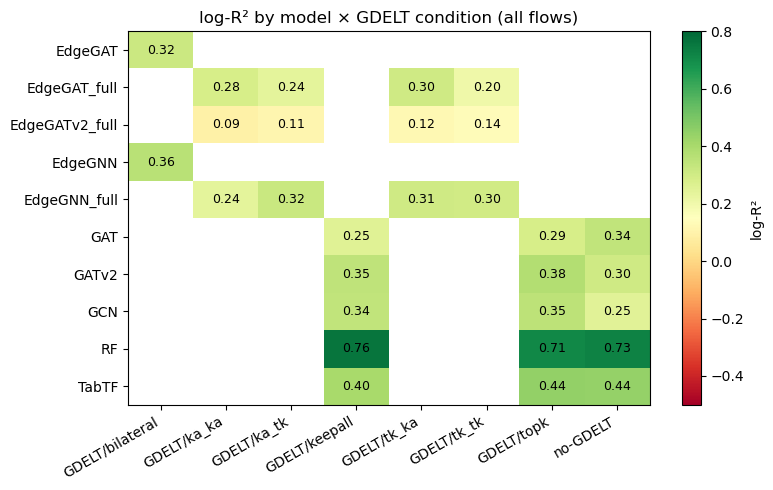

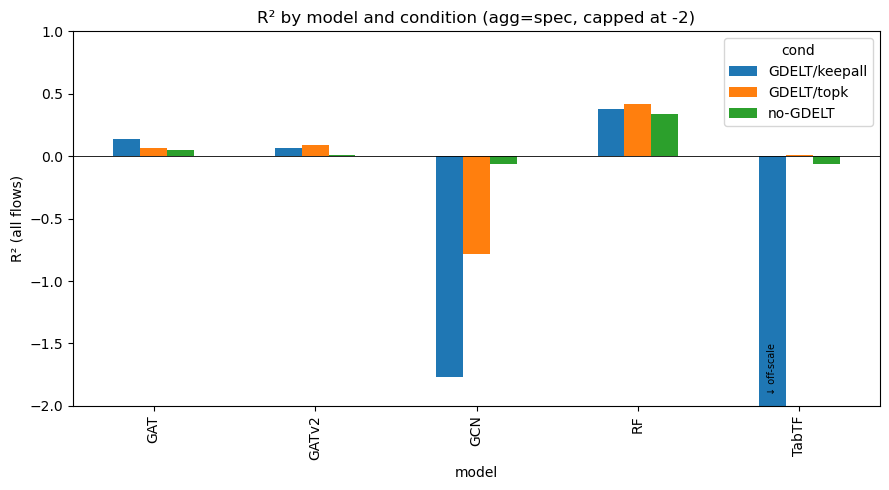

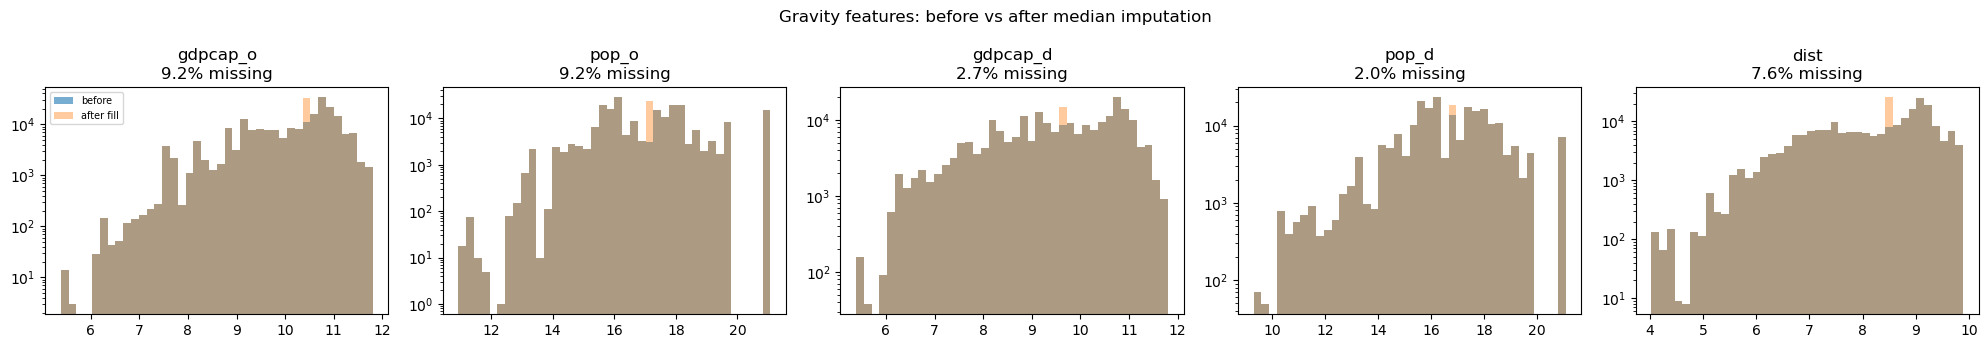

saved plots/heatmap_logr2.png, plots/r2_bars.png, plots/missing_impact.png


In [183]:
import matplotlib.pyplot as plt

r = pd.read_csv(RESULTS_FILE).drop_duplicates(
    ['model','fusion','scoring','gdelt','risk_level','agg_mode','missing','tranche'], keep='last')

# ============ 1) HEATMAP: log-R2 by model x condition (replaces scatter series) ============
sub = r[r.tranche=='all'].copy()
sub['cond'] = np.where(~sub.gdelt, 'no-GDELT', 'GDELT/'+sub.scoring.astype(str))
piv = sub.pivot_table(index='model', columns='cond', values='log_r2', aggfunc='last')

fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(piv.values, cmap='RdYlGn', vmin=-0.5, vmax=0.8, aspect='auto')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=30, ha='right')
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i,j]
        if not np.isnan(v): ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('log-R² by model × GDELT condition (all flows)')
fig.colorbar(im, label='log-R²'); plt.tight_layout()
plt.savefig('plots/heatmap_logr2_median.png', dpi=120); plt.show()

# ============ 2) BAR CHART: R2 across models/conditions (kept, now uses agg=spec) ============
main = r[r.fusion.isin(['none','concat'])]
bar = main[(main.agg_mode=='spec') & (main.tranche=='all')].copy()
bar['cond'] = np.where(~bar.gdelt, 'no-GDELT', 'GDELT/'+bar.scoring.astype(str))
piv2 = bar.pivot_table(index='model', columns='cond', values='r2')
ax = piv2.plot(kind='bar', figsize=(9,5))
plt.axhline(0, color='k', lw=0.6); plt.ylabel('R² (all flows)')
plt.ylim(-2, 1)                                  # cap the view
# mark any bar that ran off the bottom
for p in ax.patches:
    if p.get_height() < -2:
        ax.annotate('↓ off-scale', (p.get_x()+p.get_width()/2, -1.9),
                    ha='center', fontsize=7, rotation=90)
plt.title('R² by model and condition (agg=spec, capped at -2)')
plt.tight_layout(); plt.savefig('plots/r2_bars_median.png', dpi=120); plt.show()

# ============ 3) IMPUTATION DIAGNOSTIC: gravity features before vs after median-fill ============
raw = pd.read_parquet('chips.parquet')
gcols = ['gdpcap_o','pop_o','gdpcap_d','pop_d','dist']
for c in gcols: raw[c] = pd.to_numeric(raw[c], errors='coerce')
raw['refYear'] = pd.to_numeric(raw['refYear'], errors='coerce')
raw_tr = raw[raw['refYear'].between(2017,2022)]
filled = raw_tr.copy(); filled[gcols] = filled[gcols].fillna(raw_tr[gcols].median())

fig, ax = plt.subplots(1, len(gcols), figsize=(4*len(gcols), 3.5))
for j, c in enumerate(gcols):
    ax[j].hist(np.log1p(raw_tr[c].dropna()), bins=40, alpha=0.6, label='before')
    ax[j].hist(np.log1p(filled[c]),          bins=40, alpha=0.4, label='after fill')
    ax[j].set_title(f'{c}\n{raw_tr[c].isna().mean()*100:.1f}% missing'); ax[j].set_yscale('log')
    if j==0: ax[j].legend(fontsize=7)
plt.suptitle('Gravity features: before vs after median imputation')
plt.tight_layout(); plt.savefig('plots/missing_impact_median.png', dpi=120); plt.show()

print('saved plots/heatmap_logr2.png, plots/r2_bars.png, plots/missing_impact.png')

In [184]:
"""# ================================================================
# STEP 1 — per-pair TOP-K bilateral risk file
# Keeps the k highest-scored events per (Actor1, Actor2, month),
# then aggregates to pair-year. Mirrors the keep-all bilateral file.
# ================================================================
from country_codes import ISO3_2_M49
iso2m49 = {**ISO3_2_M49, 'TWN': '490'}
CRIT = ['14','17','18','19','20']
K = 10                                          # same k as the node top-k

ev = pd.read_parquet('gdelt_chip_events_2017_2023.parquet')
ev['date'] = pd.to_datetime(ev['date'], errors='coerce')
ev = ev.dropna(subset=['date','Actor1CountryCode','A|ctor2CountryCode'])
ev = ev[ev['date'].dt.year.between(2017,2023)]
ev = ev[ev['EventRootCode'].astype(str).isin(CRIT)].copy()
ev['ym']   = ev['date'].dt.to_period('M')
ev['gold'] = pd.to_numeric(ev['GoldsteinScale'], errors='coerce')
ev['ment'] = pd.to_numeric(ev['NumMentions'],   errors='coerce')
ev['score'] = ev['gold'].abs() * ev['ment']

# --- TOP-K per (Actor1, Actor2, month) ---
ev = (ev.sort_values('score', ascending=False)
        .groupby(['Actor1CountryCode','Actor2CountryCode','ym'], group_keys=False)
        .head(K))

# --- aggregate to pair-YEAR (same columns as keep-all bilateral file) ---
ev['year'] = ev['ym'].dt.year
g = ev.groupby(['Actor1CountryCode','Actor2CountryCode','year'])
b = g.agg(pair_events=('GLOBALEVENTID','size'),
          pair_score_mean=('score','mean'),
          pair_score_max=('score','max'),
          pair_gold_mean=('gold','mean')).reset_index()

# --- bridge ISO3 -> M49, same as keep-all ---
b['reporterCode'] = b['Actor1CountryCode'].map(iso2m49)
b['partnerCode']  = b['Actor2CountryCode'].map(iso2m49)
b = b.dropna(subset=['reporterCode','partnerCode'])
b['reporterCode'] = b['reporterCode'].astype(int)
b['partnerCode']  = b['partnerCode'].astype(int)

b.to_parquet('gdelt_bilateral_topk.parquet', index=False)
print('SAVED:', b.shape, '-> gdelt_bilateral_topk.parquet')

# ================= VERIFY (do this before moving on) =================
keep = pd.read_parquet('gdelt_bilateral_by_pair_year.parquet')
print('\nkeep-all columns:', list(keep.columns))
print('top-k    columns:', list(b.columns))
print('columns match:', list(keep.columns) == list(b.columns))
print('years covered:', sorted(b['year'].unique()))
print('rows keep-all:', len(keep), '| rows top-k:', len(b), '(top-k should be <= keep-all)')"""

"# ================================================================\n# STEP 1 — per-pair TOP-K bilateral risk file\n# Keeps the k highest-scored events per (Actor1, Actor2, month),\n# then aggregates to pair-year. Mirrors the keep-all bilateral file.\n# ================================================================\nfrom country_codes import ISO3_2_M49\niso2m49 = {**ISO3_2_M49, 'TWN': '490'}\nCRIT = ['14','17','18','19','20']\nK = 10                                          # same k as the node top-k\n\nev = pd.read_parquet('gdelt_chip_events_2017_2023.parquet')\nev['date'] = pd.to_datetime(ev['date'], errors='coerce')\nev = ev.dropna(subset=['date','Actor1CountryCode','A|ctor2CountryCode'])\nev = ev[ev['date'].dt.year.between(2017,2023)]\nev = ev[ev['EventRootCode'].astype(str).isin(CRIT)].copy()\nev['ym']   = ev['date'].dt.to_period('M')\nev['gold'] = pd.to_numeric(ev['GoldsteinScale'], errors='coerce')\nev['ment'] = pd.to_numeric(ev['NumMentions'],   errors='coerce')\nev['score'] 

pair-years where events differ: 2620 / 11786
